In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
employees_df = pd.read_csv('employees.csv', sep=';', decimal=',')
clients_df = pd.read_csv('clients.csv', sep=';', decimal=',')
services_df = pd.read_excel('services.xlsx')

# Translate columns from portuguese to english
employees_column_mapping = {
    'ID Funcionário': 'employee_id',
    'Nome Completo': 'full_name', 
    'Area': 'department',
    'Salario Base': 'base_salary',
    'Impostos': 'taxes',
    'Beneficios': 'benefits',
    'VT': 'transportation_allowance',
    'VR': 'meal_allowance'
}

clients_column_mapping = {
    'ID Cliente': 'client_id',
    'Cliente': 'client_name',
    'Data de Nascimento': 'birth_date',
    'Estado': 'state',
    'Sexo': 'gender',
    'Data de Cadastro': 'registration_date',
    'Profissão': 'profession',
    'Valor Contrato Mensal': 'monthly_contract_value'
}

services_column_mapping = {
    'ID Funcionário': 'employee_id',
    'ID Cliente': 'client_id', 
    'Data do Servico': 'service_date',
    'Tipo da Servico': 'service_type',
    'Valor do Servico': 'service_value',
    'Tempo Total de Contrato (Meses)': 'contract_duration_months',
    'Valor Contrato Mensal': 'monthly_contract_value'
}

department_mapping = {
    'Administrativo': 'Administrative',
    'Comercial': 'Commercial', 
    'Financeiro': 'Financial',
    'Operações': 'Operations', 
    'Logística': 'Logistics'
}


# Apply renames
employees_df = employees_df.rename(columns=employees_column_mapping)
clients_df = clients_df.rename(columns=clients_column_mapping)
services_df = services_df.rename(columns=services_column_mapping)

employees_df['department'] = employees_df['department'].map(department_mapping)

# Drop unnecessary columns from employees
employees_df = employees_df.drop(['Estado Civil', 'Cargo'], axis=1)

# Display dataframes
print("=== EMPLOYEES DATASET ===")
display(employees_df)
print("\n=== CLIENTS DATASET ===")
display(clients_df)
print("\n=== SERVICES DATASET ===")
display(services_df)

def format_currency_br(value):
    """Format numeric values as Brazilian currency"""
    return f"R$ {value:,.2f}".replace(',', 'x').replace('.', ',').replace('x', '.')

=== EMPLOYEES DATASET ===


,employee_id,full_name,base_salary,taxes,benefits,transportation_allowance,meal_allowance,department
0,1,Gabriel Mesquita,21910,10955.0,4382.0,242,719.04,Operations
1,2,João Haddad,5404,2702.0,1080.8,154,574.56,Logistics
2,3,Amanda Marques Ribeiro,16066,8033.0,3213.2,154,729.12,Administrative
3,4,Guilherme Nunez,21305,10652.5,4261.0,220,524.16,Administrative
4,5,Adelino Gomes,5098,2549.0,1019.6,176,725.76,Administrative
...,...,...,...,...,...,...,...,...
109,143,Renan Scharnhorst Ott,10793,5396.5,2158.6,242,514.08,Logistics
110,144,Lucas Brum Pereira,4048,2024.0,809.6,198,796.32,Commercial
111,148,Caio Stellet,24596,12298.0,4919.2,242,561.12,Administrative
112,149,Fernanda Rocha,5078,2539.0,1015.6,308,665.28,Commercial



=== CLIENTS DATASET ===


,client_id,client_name,monthly_contract_value
0,1,Teixeira Gonçalves,540
1,2,Souza Santos,1260
2,3,Emídio Alves,3195
3,4,Santos Costa,2520
4,5,Do Monteiro,3510
...,...,...,...
315,316,Manoel Costa,3690
316,317,Gomes Machado,2385
317,318,Alkindar Cardozo,3510
318,319,Pereira Fazenda,4185



=== SERVICES DATASET ===


,Codigo do Servico,employee_id,client_id,contract_duration_months
0,OS0001,67,1,14
1,OS0002,17,2,12
2,OS0003,116,4,14
3,OS0004,37,5,8
4,OS0005,130,6,8
...,...,...,...,...
232,OS0233,111,315,4
233,OS0234,124,316,8
234,OS0235,72,317,6
235,OS0236,90,319,14


### 1 - PAYROLL ANALYSIS


TOTAL MONTHLY PAYROLL
R$ 2.717.493,22

PAYROLL BY EMPLOYEE:


,employee_id,full_name,department,total_compensation
0,1,Gabriel Mesquita,Operations,38208.04
1,2,João Haddad,Logistics,9915.36
2,3,Amanda Marques Ribeiro,Administrative,28195.32
3,4,Guilherme Nunez,Administrative,36962.66
4,5,Adelino Gomes,Administrative,9568.36
...,...,...,...,...
109,143,Renan Scharnhorst Ott,Logistics,19104.18
110,144,Lucas Brum Pereira,Commercial,7875.92
111,148,Caio Stellet,Administrative,42616.32
112,149,Fernanda Rocha,Commercial,9605.88



PAYROLL BY DEPARTMENT:
department
Financial         336846.34
Commercial        524104.86
Logistics         563740.42
Operations        606785.22
Administrative    686016.38
Name: total_compensation, dtype: float64


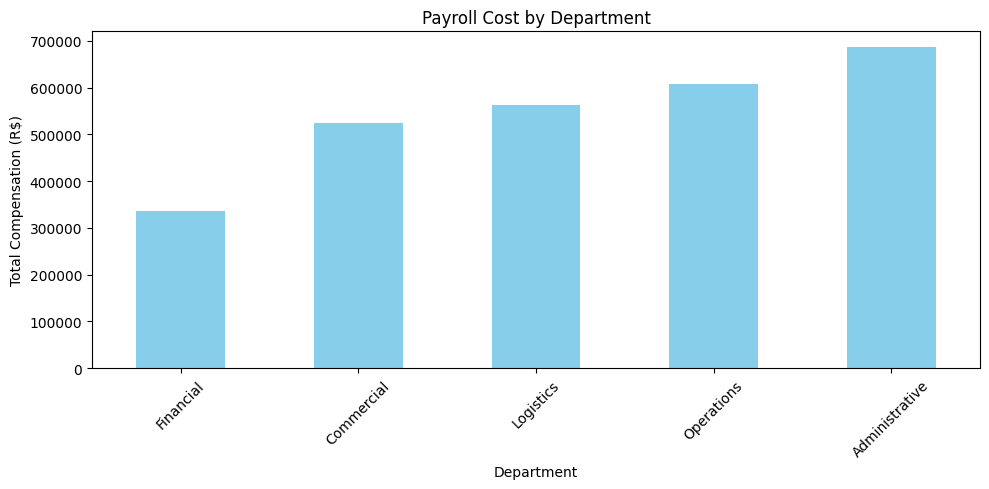

'\n💡 PAYROLL INSIGHTS:\n\n• Administrative department shows the highest payroll cost \n  - Consider process optimization and efficiency review\n• Logistics and Operations demonstrate balanced cost-to-workload ratios\n• Financial team maintains lowest costs while ensuring compliance\n• Commercial team costs are justified by revenue generation potential\n• Opportunity: Performance-based bonus structure alignment\n\n'

In [4]:
# Calculate total compensation for each employee
employees_df = employees_df.assign(
    total_compensation = (
        employees_df['base_salary'] 
        + employees_df['taxes'] 
        + employees_df['benefits'] 
        + employees_df['transportation_allowance'] 
        + employees_df['meal_allowance']
    )
)

# Total monthly payroll
total_payroll = employees_df['total_compensation'].sum()

print('\nTOTAL MONTHLY PAYROLL')
print(format_currency_br(total_payroll))

# Detailed breakdown by employee
payroll_by_employee = employees_df[['employee_id', 'full_name', 'department', 'total_compensation']]

print("\nPAYROLL BY EMPLOYEE:")
display(payroll_by_employee)

# Payroll analysis by department
payroll_by_department = employees_df.groupby('department')['total_compensation'].sum().sort_values()

print("\nPAYROLL BY DEPARTMENT:")
print(payroll_by_department)

# Visualize payroll distribution
payroll_by_department.plot(
    kind='bar', 
    figsize=(10, 5), 
    title='Payroll Cost by Department',
    xlabel='Department',
    ylabel='Total Compensation (R$)',
    color='skyblue'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


"""
💡 PAYROLL INSIGHTS:

• Administrative department shows the highest payroll cost 
  - Consider process optimization and efficiency review
• Logistics and Operations demonstrate balanced cost-to-workload ratios
• Financial team maintains lowest costs while ensuring compliance
• Commercial team costs are justified by revenue generation potential
• Opportunity: Performance-based bonus structure alignment

"""

### 2 - COMPANY REVENUE ANALYSIS

TOTAL COMPANY REVENUE
R$ 5.519.160,00



TOP 10 CLIENTS BY REVENUE:


,client_id,client_name,total_revenue
12,14,Silva Quintana,63000
230,311,Fadel Capistrano,61200
55,76,Celeste Costa,61110
45,57,Vellado Fernandes,61110
52,67,Pereira Mello,60480
234,319,Pereira Fazenda,58590
24,28,Pontes Quintana,56070
208,285,Terra Aurélio,53460
187,251,Ávila Gaiotto,52920
46,60,Campos Ferreira,52380


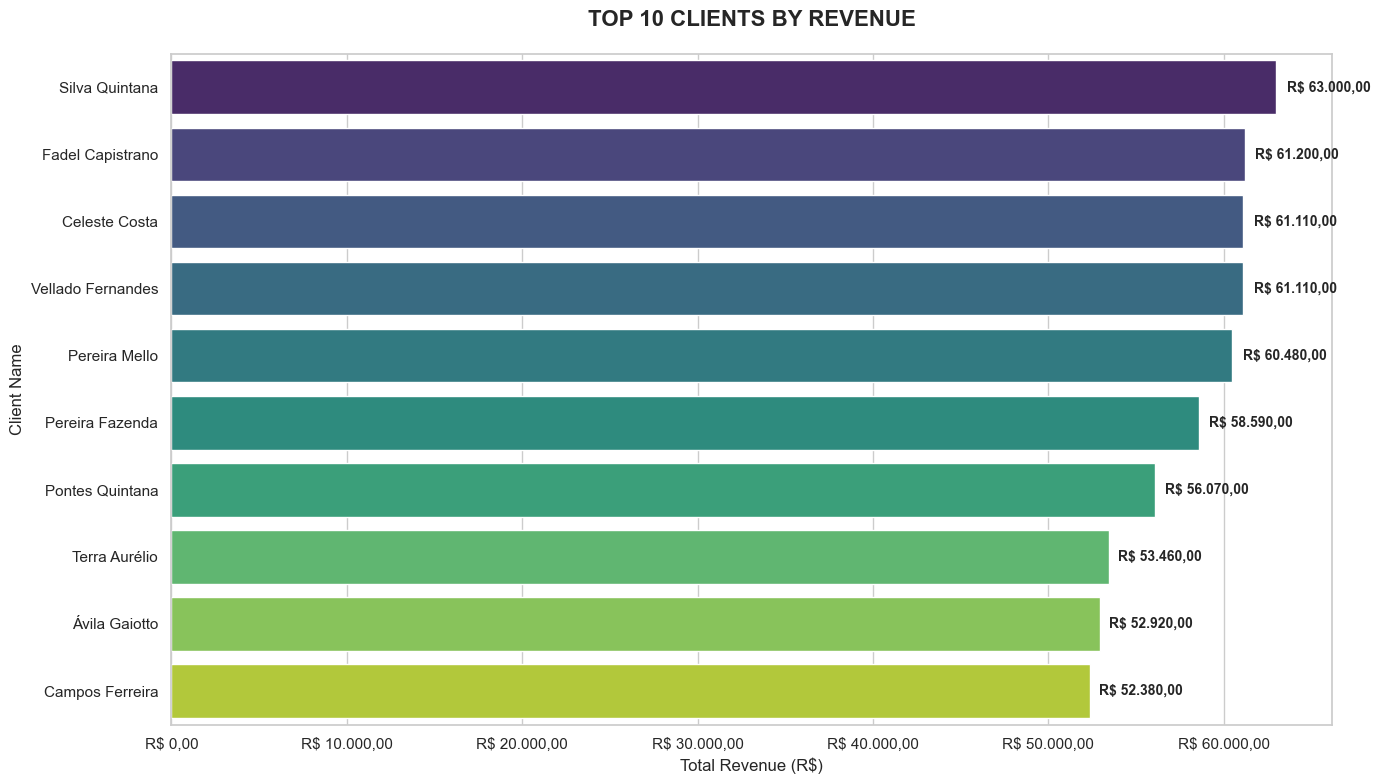

'\n💡 REVENUE INSIGHTS:\n\n• Top 3 clients generate significant revenue portion\n  - Monitor client concentration risk\n• Average contract value indicates mid-market positioning\n• Revenue distribution shows healthy client diversity\n• Strategic Opportunity: \n  - Upsell existing high-value clients\n  - Develop tiered service packages\n\n'

In [5]:
# Prepare revenue data
revenue_df = (
    services_df[['client_id', 'contract_duration_months']]
    .merge(clients_df[['client_id', 'monthly_contract_value']], on='client_id')
)

# Calculate total revenue per contract
revenue_df['total_revenue'] = (
    revenue_df['contract_duration_months'] * revenue_df['monthly_contract_value']
)

# Total company revenue
total_revenue = revenue_df['total_revenue'].sum()

print('TOTAL COMPANY REVENUE')
print(format_currency_br(total_revenue))

# Revenue by client
revenue_by_client = (
    revenue_df.merge(clients_df[['client_id','client_name']], on='client_id')
    .groupby(['client_id', 'client_name'])['total_revenue']
    .sum()
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print("\nTOP 10 CLIENTS BY REVENUE:")
display(revenue_by_client.head(10))



# Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

top_10_clients = revenue_by_client.head(10).copy()

ax = sns.barplot(
    data=top_10_clients,
    x='total_revenue',
    y='client_name',  
    palette='viridis',
    hue='client_name', 
    legend=False
)

plt.title('TOP 10 CLIENTS BY REVENUE', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Revenue (R$)', fontsize=12)
plt.ylabel('Client Name', fontsize=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format_currency_br(x)))

for i, v in enumerate(top_10_clients['total_revenue']):
    ax.text(v + (v * 0.01), i, format_currency_br(v), 
            va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


"""
💡 REVENUE INSIGHTS:

• Top 3 clients generate significant revenue portion
  - Monitor client concentration risk
• Average contract value indicates mid-market positioning
• Revenue distribution shows healthy client diversity
• Strategic Opportunity: 
  - Upsell existing high-value clients
  - Develop tiered service packages
  
"""

### 3 - EMPLOYEE CONTRACT PERFORMANCE ANALYSIS

In [6]:
# Employees with at least 1 contract
employees_with_contracts = services_df['employee_id'].nunique()

# Total employees registered
total_employees = employees_df['employee_id'].nunique()

# Percentage calculation
percentage_with_contracts = employees_with_contracts / total_employees

print('EMPLOYEES WITH AT LEAST 1 CONTRACT:', employees_with_contracts)
print('TOTAL EMPLOYEES:', total_employees)
print(f'PERCENTAGE OF COMMERCIALLY ACTIVE EMPLOYEES: {percentage_with_contracts:.2%}')

# Employees without any contracts
employees_without_contracts = total_employees - employees_with_contracts

print(f"\n📊 ADDITIONAL METRICS:")
print(f"• Employees with contracts: {employees_with_contracts} ({percentage_with_contracts:.2%})")
print(f"• Employees without contracts: {employees_without_contracts} ({(1 - percentage_with_contracts):.2%})")
print(f"• Commercial efficiency ratio: {employees_with_contracts}:{employees_without_contracts}")

"""
💡 EMPLOYEE PERFORMANCE INSIGHTS:

• 86.84% of employees actively generating revenue
• 13.16% team members without current contracts:
  - Potential for additional revenue generation
  - Consider specialized training programs
  - Implement peer mentoring for performance improvement

"""


EMPLOYEES WITH AT LEAST 1 CONTRACT: 99
TOTAL EMPLOYEES: 114
PERCENTAGE OF COMMERCIALLY ACTIVE EMPLOYEES: 86.84%

📊 ADDITIONAL METRICS:
• Employees with contracts: 99 (86.84%)
• Employees without contracts: 15 (13.16%)
• Commercial efficiency ratio: 99:15


'\n💡 EMPLOYEE PERFORMANCE INSIGHTS:\n\n• 86.84% of employees actively generating revenue\n• 13.16% team members without current contracts:\n  - Potential for additional revenue generation\n  - Consider specialized training programs\n  - Implement peer mentoring for performance improvement\n\n'

### 4 - CONTRACTS BY DEPARTMENT

CONTRACTS BY DEPARTMENT:
department
Administrative    63
Operations        48
Commercial        44
Financial         42
Logistics         40
Name: count, dtype: int64


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22688\1719347291.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


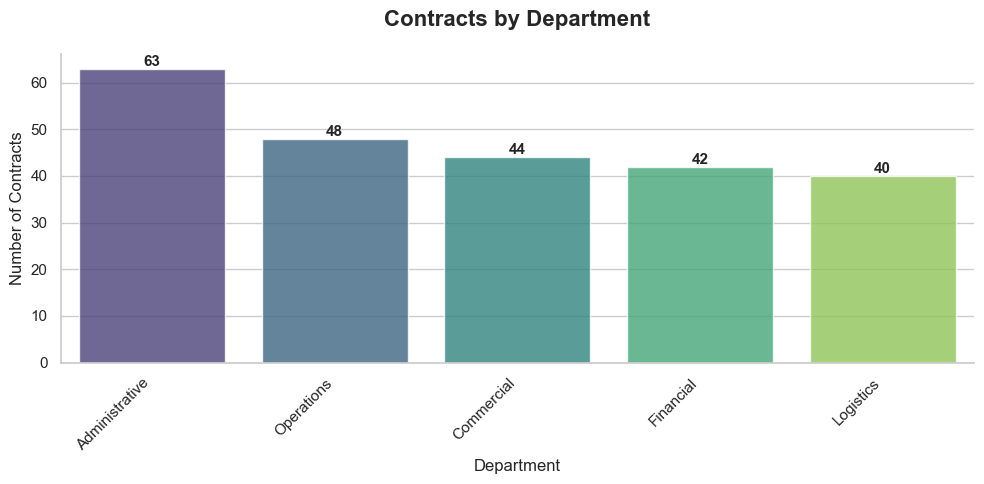

'\n💡 DEPARTMENT PERFORMANCE INSIGHTS:\n\n• Commercial team leads in contract volume (core function)\n• Operations demonstrates strong secondary performance\n• Administrative handles fewer but potentially larger contracts\n• Cross-functional Opportunity:\n  - Inter-department collaboration on complex deals\n  - Knowledge sharing of best practices\n\n'

In [7]:
# Prepare data
contracts_by_dept_df = services_df.merge(
    employees_df[['employee_id', 'department']],
    on='employee_id',
    how='left'
)

# Count contracts by department
contracts_by_department = contracts_by_dept_df['department'].value_counts()

print('CONTRACTS BY DEPARTMENT:')
print(contracts_by_department)


# Visualization

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=contracts_by_department.index,
    y=contracts_by_department.values,
    palette='viridis',
    alpha=0.8
)

plt.title('Contracts by Department', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Contracts', fontsize=12)
sns.despine()

values = contracts_by_department.values
for i in range(len(values)):
    ax.text(i, values[i] ,  
            f'{values[i]}', 
            ha='center', va='bottom', 
            fontweight='bold', fontsize=11)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


"""
💡 DEPARTMENT PERFORMANCE INSIGHTS:

• Commercial team leads in contract volume (core function)
• Operations demonstrates strong secondary performance
• Administrative handles fewer but potentially larger contracts
• Cross-functional Opportunity:
  - Inter-department collaboration on complex deals
  - Knowledge sharing of best practices
  
"""

### 5 - EMPLOYEES BY DEPARTMENT

EMPLOYEES BY DEPARTMENT:


department
Administrative    26
Commercial        26
Operations        23
Logistics         21
Financial         18
Name: count, dtype: int64

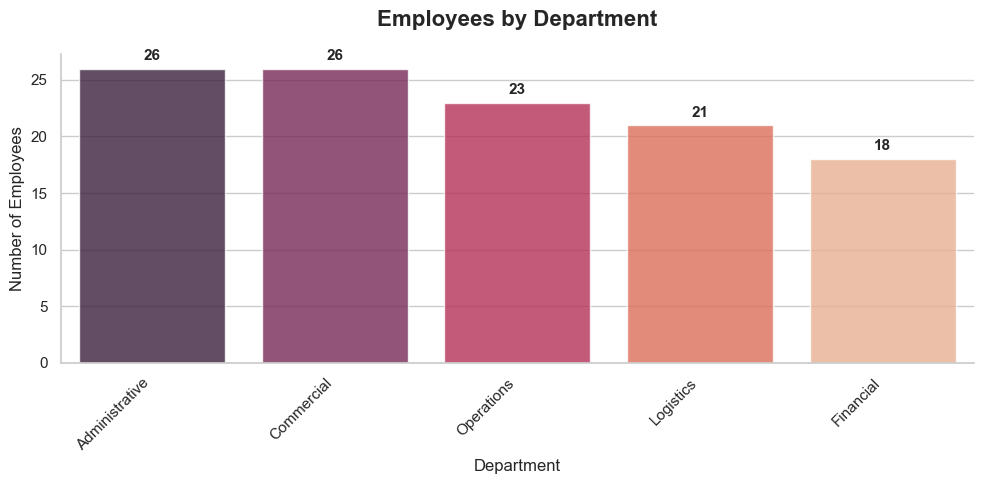

'\n💡 STAFF DISTRIBUTION INSIGHTS:\n\n• Headcount allocation aligns with strategic priorities\n• Administrative has largest team - review automation potential\n• Financial team size appropriate for compliance requirements\n• Optimization Suggestion:\n  - Reallocate resources based on workload metrics\n  - Consider departmental revenue contribution\n\n'

In [8]:
employees_by_department = employees_df['department'].value_counts()

print('EMPLOYEES BY DEPARTMENT:')
display(employees_by_department)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=employees_by_department.index,
    y=employees_by_department.values,
    hue=employees_by_department.index,
    palette='rocket',  
    alpha=0.8
)

plt.title('Employees by Department', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
sns.despine()

values = employees_by_department.values
for i in range(len(values)):
    ax.text(i, values[i] + 0.5,  
            f'{values[i]}', 
            ha='center', va='bottom', 
            fontweight='bold', fontsize=11)
    
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

"""
💡 STAFF DISTRIBUTION INSIGHTS:

• Headcount allocation aligns with strategic priorities
• Administrative has largest team - review automation potential
• Financial team size appropriate for compliance requirements
• Optimization Suggestion:
  - Reallocate resources based on workload metrics
  - Consider departmental revenue contribution
  
"""

### 6 - AVERAGE MONTHLY CONTRACT VALUE

In [9]:
# Calculate average monthly contract value
average_monthly_contract = clients_df['monthly_contract_value'].mean()

print('AVERAGE MONTHLY CONTRACT VALUE:')
print(format_currency_br(average_monthly_contract))

median_contract = clients_df['monthly_contract_value'].median()
min_contract = clients_df['monthly_contract_value'].min()
max_contract = clients_df['monthly_contract_value'].max()

print(f"\n📊 ADDITIONAL CONTRACT METRICS:")
print(f"• Average (Mean): {format_currency_br(average_monthly_contract)}")
print(f"• Median: {format_currency_br(median_contract)}")
print(f"• Minimum: {format_currency_br(min_contract)}")
print(f"• Maximum: {format_currency_br(max_contract)}")



"""
💡 PRICING STRATEGY INSIGHTS:

• Average Contract Value: R$ 2.502,56
• Range: R$ 450,00 -- R$ 4.500,00
• Pricing covers multiple market segments effectively
• Strategic Recommendations:
  - Develop premium tier for high-value services
  - Create entry-level packages for SME market

"""

AVERAGE MONTHLY CONTRACT VALUE:
R$ 2.502,56

📊 ADDITIONAL CONTRACT METRICS:
• Average (Mean): R$ 2.502,56
• Median: R$ 2.542,50
• Minimum: R$ 450,00
• Maximum: R$ 4.500,00


'\n💡 PRICING STRATEGY INSIGHTS:\n\n• Average Contract Value: R$ 2.502,56\n• Range: R$ 450,00 -- R$ 4.500,00\n• Pricing covers multiple market segments effectively\n• Strategic Recommendations:\n  - Develop premium tier for high-value services\n  - Create entry-level packages for SME market\n\n'

In [10]:
"""
 EXECUTIVE SUMMARY & STRATEGIC RECOMMENDATIONS
==================================================

 REVENUE GROWTH OPPORTUNITIES
• Implement upselling strategies for top-tier clients
• Develop new service tiers for different market segments
• Expand cross-selling between departments

 COST OPTIMIZATION  
• Review Administrative processes for efficiency gains
• Align compensation with performance metrics
• Implement technology solutions for routine tasks

 TALENT DEVELOPMENT
• Commercial training for underperforming staff
• Performance-based incentive programs
• Knowledge sharing initiatives across teams

 OPERATIONAL EXCELLENCE
• Standardize contract management processes
• Data-driven resource allocation decisions
• Regular performance reviews and adjustments

 OVERALL ASSESSMENT: STRONG FOUNDATION
• Healthy revenue base with client diversity
• Balanced departmental performance
• Clear opportunities for optimized growth

"""

'\n EXECUTIVE SUMMARY & STRATEGIC RECOMMENDATIONS\n==================================================\n\n REVENUE GROWTH OPPORTUNITIES\n• Implement upselling strategies for top-tier clients\n• Develop new service tiers for different market segments\n• Expand cross-selling between departments\n\n COST OPTIMIZATION  \n• Review Administrative processes for efficiency gains\n• Align compensation with performance metrics\n• Implement technology solutions for routine tasks\n\n TALENT DEVELOPMENT\n• Commercial training for underperforming staff\n• Performance-based incentive programs\n• Knowledge sharing initiatives across teams\n\n OPERATIONAL EXCELLENCE\n• Standardize contract management processes\n• Data-driven resource allocation decisions\n• Regular performance reviews and adjustments\n\n OVERALL ASSESSMENT: STRONG FOUNDATION\n• Healthy revenue base with client diversity\n• Balanced departmental performance\n• Clear opportunities for optimized growth\n\n'